In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import math
import torch 
import torch.nn as nn 
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.optim as optim
import torch.nn.functional as F


In [2]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

g = torch.Generator()
g.manual_seed(42)

images = datasets.ImageFolder(
    root="./archive (11)/Train/",
    transform= transform
)

images_loader = DataLoader(
    images, 
    batch_size= 64,
    shuffle= True,
    generator=g
    
)





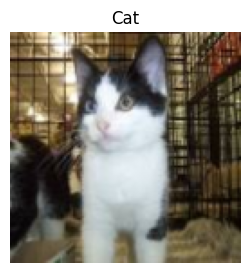

In [3]:
def plot_image(image_label_tensor, index):
    image = image_label_tensor[index][0]
    label = image_label_tensor[index][1]
    image = image.permute(1, 2, 0)
    
    plt.figure(figsize=(3,3))
    plt.imshow(image)
    plt.title(f"{'Dog' if label==1 else 'Cat'}")
    plt.axis("off")
    plt.show()
    
    
plot_image(images, 4)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

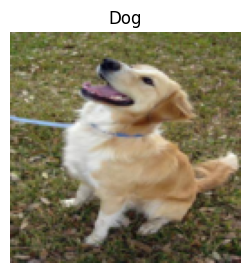

In [5]:
from torch.utils.data import random_split

train_size = math.floor(0.8* len(images))
valid_size = len(images) - train_size

train_dataset, valid_dataset = random_split(
    images,
    [train_size, valid_size],
    generator= g
)

train_loader = DataLoader(
    train_dataset, batch_size=64, shuffle=True, 
    pin_memory=True, num_workers=4, generator=g
)
valid_loader = DataLoader(
    valid_dataset, batch_size=64, shuffle=False, 
    pin_memory=True, num_workers=4, generator=g
)

plot_image(valid_dataset, 6)


# CNN

In [6]:
input_channel, height, width = images[0][0].shape
output_dim = 1


In [9]:
curve_loss = []
curve_acc = []

class CatDogCnn(nn.Module):
    def __init__(self, smaple_shape, input_channel, hidden_dims, output_dim, 
                kernel_sizes = None, strides = None, paddings = None, dropouts = None):
        super().__init__()
        
        if kernel_sizes is None:
            self.kernel_sizes = [3 for _ in range(len(hidden_dims))]
        else:
            self.kernel_sizes = kernel_sizes
        if strides is None:
            self.strides = [1 for _ in range(len(hidden_dims))]
        else:
            self.strides = strides
        if paddings is None:
            self.paddings = [k // 2 for k in kernel_sizes]
        else:
            self.paddings = paddings
        if dropouts is None:
            self.dropouts = [0.2 for _ in range(len(hidden_dims)+1)]
        else:
            self.dropouts = dropouts
            
        self.hidden_dims = hidden_dims
        self.output_dim = output_dim   
        
            
        current_channel = input_channel
        layers = []
        H, W = smaple_shape
        
        for i in range(len(hidden_dims)):
            layers.append(
                nn.Conv2d(in_channels=current_channel, out_channels= self.hidden_dims[i], 
                          kernel_size= self.kernel_sizes[i], stride=self.strides[i], padding= self.paddings[i])
            )
            layers.append(nn.BatchNorm2d(hidden_dims[i]))
            layers.append(nn.Dropout2d(self.dropouts[i]))
            layers.append(nn.GELU())
            
            layers.append(nn.MaxPool2d(2))
            H = math.floor((H + 2 * self.paddings[i] - self.kernel_sizes[i]) / self.strides[i]) + 1
            W = math.floor((W + 2 * self.paddings[i] - self.kernel_sizes[i]) / self.strides[i]) + 1
            H = H // 2
            W = W // 2
            
            current_channel = hidden_dims[i]
            
        layers.append(nn.Flatten()) 
        layers.append(nn.Dropout(self.dropouts[-1]))
        layers.append(
            nn.Linear(self.hidden_dims[-1]*H*W, self.output_dim )
        )
        self.layers = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.layers(x)
    


model = CatDogCnn((height,width), input_channel= input_channel, hidden_dims=[64, 128, 256, 128],
                  output_dim = output_dim, kernel_sizes= [5, 3, 3, 3]).to(device)  


optimizer = optim.Adam(model.parameters(), lr = 0.0001, weight_decay=1e-5 )
criterion = nn.BCEWithLogitsLoss()

n_epochs = 12


for epoch in range(n_epochs): 
    model.train()
    train_loss = 0
    
    for x_train_batch, y_train_batch in train_loader:
        x_train_batch = x_train_batch.to(device)
        y_train_batch = y_train_batch.float().unsqueeze(1).to(device)
        optimizer.zero_grad()
        train_logits = model(x_train_batch)
        loss = criterion(train_logits, y_train_batch)
        loss.backward()
        optimizer.step()
    
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    
    model.eval()
    val_loss_total = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for x_valid_batch, y_valid_batch in valid_loader:
            x_valid_batch = x_valid_batch.to(device)
            y_valid_batch = y_valid_batch.float().unsqueeze(1).to(device)
            
            val_logits = model(x_valid_batch)
            val_loss = criterion(val_logits, y_valid_batch)
            
            preds = (torch.sigmoid(val_logits) > 0.5).long()
            
            correct += (preds.squeeze(1) == y_valid_batch.squeeze(1).long()).sum().item()
            val_loss_total += val_loss.item()
            total += y_valid_batch.size(0)


    validating_loss = val_loss_total / len(valid_loader)
    val_acc = correct / total
    curve_loss.append(validating_loss)
    curve_acc.append(val_acc)
    
    if (epoch + 1) % 1 == 0:
        print(f"Epoch [{epoch+1}/{n_epochs}] | train_loss: {train_loss:.4f} | val_loss: {validating_loss:.4f} | val_acc: {val_acc:.4f}")

            
    
    
    
    
        
        

Epoch [1/12] | train_loss: 0.6053 | val_loss: 0.5503 | val_acc: 0.7093
Epoch [2/12] | train_loss: 0.5242 | val_loss: 0.4823 | val_acc: 0.7672
Epoch [3/12] | train_loss: 0.4748 | val_loss: 0.4433 | val_acc: 0.7939
Epoch [4/12] | train_loss: 0.4445 | val_loss: 0.4290 | val_acc: 0.8040
Epoch [5/12] | train_loss: 0.4179 | val_loss: 0.4710 | val_acc: 0.7746
Epoch [6/12] | train_loss: 0.3988 | val_loss: 0.3933 | val_acc: 0.8224
Epoch [7/12] | train_loss: 0.3735 | val_loss: 0.3784 | val_acc: 0.8330
Epoch [8/12] | train_loss: 0.3600 | val_loss: 0.3664 | val_acc: 0.8342
Epoch [9/12] | train_loss: 0.3411 | val_loss: 0.3612 | val_acc: 0.8383
Epoch [10/12] | train_loss: 0.3242 | val_loss: 0.3402 | val_acc: 0.8510
Epoch [11/12] | train_loss: 0.3100 | val_loss: 0.3267 | val_acc: 0.8575
Epoch [12/12] | train_loss: 0.2997 | val_loss: 0.3149 | val_acc: 0.8685


Epoch [14/12] | train_loss: 0.2834 | val_loss: 0.3152 | val_acc: 0.8615
Epoch [15/12] | train_loss: 0.2729 | val_loss: 0.3050 | val_acc: 0.8706
Epoch [16/12] | train_loss: 0.2642 | val_loss: 0.2982 | val_acc: 0.8734
Epoch [17/12] | train_loss: 0.2467 | val_loss: 0.2903 | val_acc: 0.8719
Epoch [18/12] | train_loss: 0.2386 | val_loss: 0.3002 | val_acc: 0.8687
Epoch [19/12] | train_loss: 0.2258 | val_loss: 0.2888 | val_acc: 0.8799
Epoch [20/12] | train_loss: 0.2218 | val_loss: 0.2804 | val_acc: 0.8797
Epoch [21/12] | train_loss: 0.2102 | val_loss: 0.2823 | val_acc: 0.8801


In [15]:
torch.save(model, "./model/attempt2model.pth")

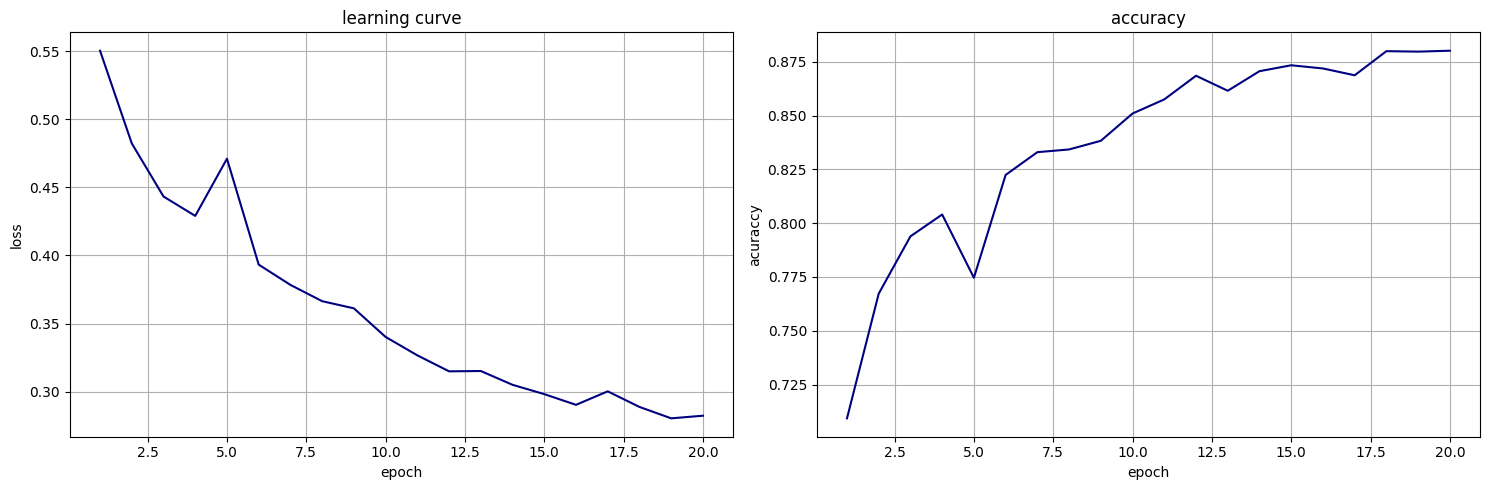

In [21]:

plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.grid()
plt.plot(list(range(1, 21)), curve_loss, color="navy")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("learning curve")

plt.subplot(1,2,2)
plt.plot(list(range(1, 20+1)), curve_acc, color="navy")
plt.xlabel("epoch")
plt.ylabel("acuraccy")
plt.grid()
plt.title("accuracy")

plt.tight_layout()
plt.show()



In [18]:
test_images = datasets.ImageFolder(
    root = "./archive (11)/Test",
    transform= transform
    )

test_images_loader = DataLoader(
    test_images, 
    batch_size= 256,
    shuffle= True,
    generator= g
)


from sklearn.metrics import confusion_matrix, classification_report



In [19]:
model.eval()
y_hat = []
y_test = []

with torch.no_grad():
    for images, labels in test_images_loader:
        img = images.to(device)
        lab = labels.to(device)
        test_logits = model(img)
        preds = (torch.sigmoid(test_logits)>0.5).long()
        y_hat.append(preds.cpu())
        y_test.append(labels.cpu())
        
        
all_y_hat = torch.cat(y_hat).numpy()
all_y_test = torch.cat(y_test).numpy()


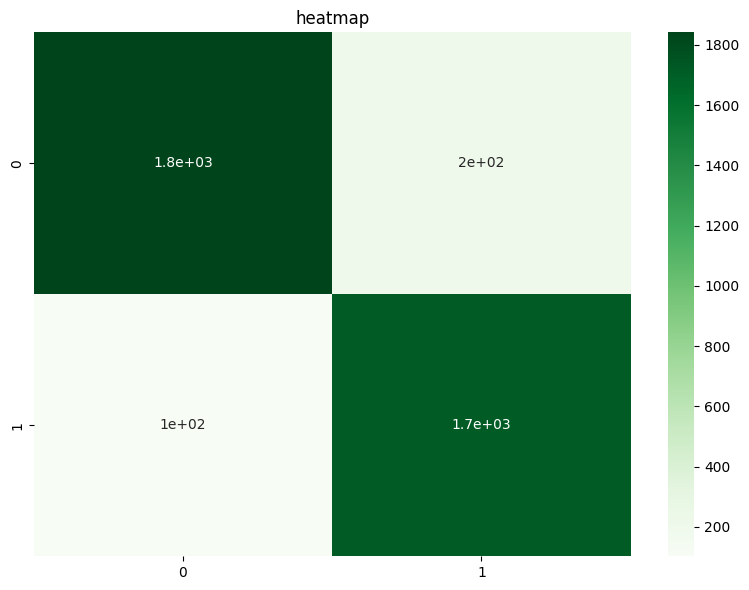

              precision    recall  f1-score   support

           0       0.95      0.90      0.92      2046
           1       0.89      0.94      0.92      1817

    accuracy                           0.92      3863
   macro avg       0.92      0.92      0.92      3863
weighted avg       0.92      0.92      0.92      3863



In [20]:
from seaborn import heatmap

report = classification_report(all_y_hat,all_y_test)
cm = confusion_matrix( all_y_hat,all_y_test)

plt.figure(figsize=(8,6))
heatmap(cm, annot=True, cmap="Greens")
plt.title("heatmap")
plt.tight_layout()
plt.show()

print(report)


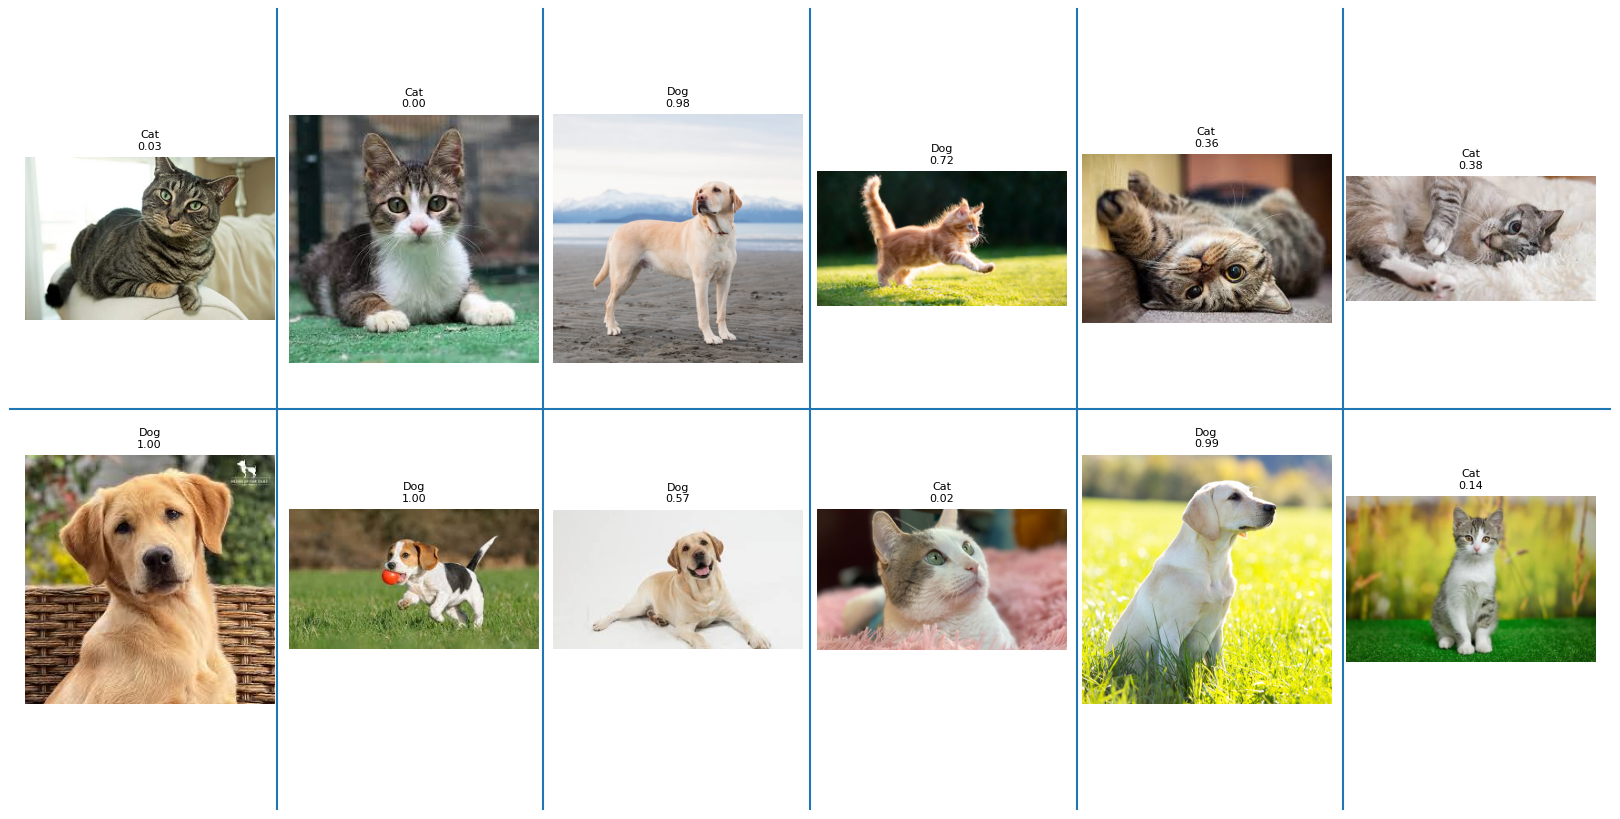

In [34]:
import os
import torch
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

model.eval()

test_folder = "./my_test_images"

transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

supported_formats = (".jpg", ".jpeg", ".png", ".webp", ".avif", ".bmp", ".jfif")

images = []
titles = []

with torch.no_grad():
    for filename in os.listdir(test_folder):
        
        if len(images) == 12:
            break
        
        if not filename.lower().endswith(supported_formats):
            continue
        
        path = os.path.join(test_folder, filename)
        
        try:
            image = Image.open(path).convert("RGB")
        except:
            continue
        
        image_tensor = transform(image).unsqueeze(0).to(device)
        
        output = model(image_tensor)
        prob = torch.sigmoid(output)
        pred = (prob > 0.5).long().item()
        
        label = "Dog" if pred == 1 else "Cat"
        
        images.append(image)
        titles.append(f"{label}\n{prob.item():.2f}")


fig, axes = plt.subplots(2, 6, figsize=(16,8))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i])
    ax.set_title(titles[i], fontsize=8)
    ax.axis("off")
plt.tight_layout()
for x in range(1, 6):
    fig.lines.append(plt.Line2D([x/6, x/6], [0, 1], transform=fig.transFigure))
fig.lines.append(plt.Line2D([0, 1], [0.5, 0.5], transform=fig.transFigure))
plt.show()


### 1/12 mistake - we'll see what happens
#### unfortunately i have niether bore or computational power for training a deeper model